In [33]:
# ติดตั้ง library
!pip install youtube-comment-downloader pandas

In [44]:
# ติดตั้ง library: pip install youtube-comment-downloader pandas
from youtube_comment_downloader import YoutubeCommentDownloader, SORT_BY_RECENT
import pandas as pd

def scrape_youtube_comments(video_url, max_comments=300):
    downloader = YoutubeCommentDownloader()
    generator = downloader.get_comments_from_url('https://www.youtube.com/watch?v=QvxuR8uLPFs', sort_by=SORT_BY_RECENT)
    
    comments = []
    for count, comment in enumerate(generator):
        if count >= max_comments: break
        comments.append({
            'Author': comment['author'],
            'Comment Text': comment['text']
        })
    
    df = pd.DataFrame(comments)
    df.to_csv('youtube_comments.csv', index=False, encoding='utf-8-sig')
    print(f"บันทึก {len(df)} คอมเมนต์ลงไฟล์ youtube_comments.csv")
    return df

# ตัวอย่าง: url = 'https://www.youtube.com/watch?v=QvxuR8uLPFs'
# df = scrape_youtube_comments(url)

In [45]:
# URL จากรูปภาพที่ให้มา
url = 'https://youtu.be/iogcY_4xGjo?si=yX71k-5LL2baunRC'
df = scrape_youtube_comments(url)
df.head()

บันทึก 14 คอมเมนต์ลงไฟล์ youtube_comments.csv


,Author,Comment Text
0,@ShawhinTalebi,🤝 Work with me: https://www.shawhintalebi.com
1,@mamun001,Thank you!
2,@karannahar8125,Interesting. However when considering embeddin...
3,@-hedredo8420,"Hey Shaw, thanks for this great vidéo, gave me..."
4,@tyrealq,Great content—very hands-on! Thank you so much...


In [46]:
import google.generativeai as genai
import numpy as np
from dotenv import load_dotenv
import os

# ตั้งค่า API Key ของคุณ
load_dotenv(override=True) # Load environment variables from .env file
api_key = os.getenv("GOOGLE_API_KEY")
os.environ["GOOGLE_API_KEY"] = api_key
genai.configure(api_key=api_key)

def get_gemini_embeddings(texts):
    # ใช้โมเดล text-embedding-004 ของ Google
    model = 'models/text-embedding-004'
    result = genai.embed_content(model=model, content=texts, task_type="clustering")
    return np.array(result['embedding'])

# โหลดข้อมูลและทำ Embeddings
df = pd.read_csv('youtube_comments.csv').dropna()
print("กำลังประมวลผล Embeddings...")
embeddings = get_gemini_embeddings(df['Comment Text'].tolist())

# สร้าง DataFrame สำหรับ Embeddings เพื่อนำไปเข้า Clustering
df_embeddings = pd.DataFrame(embeddings)

กำลังประมวลผล Embeddings...


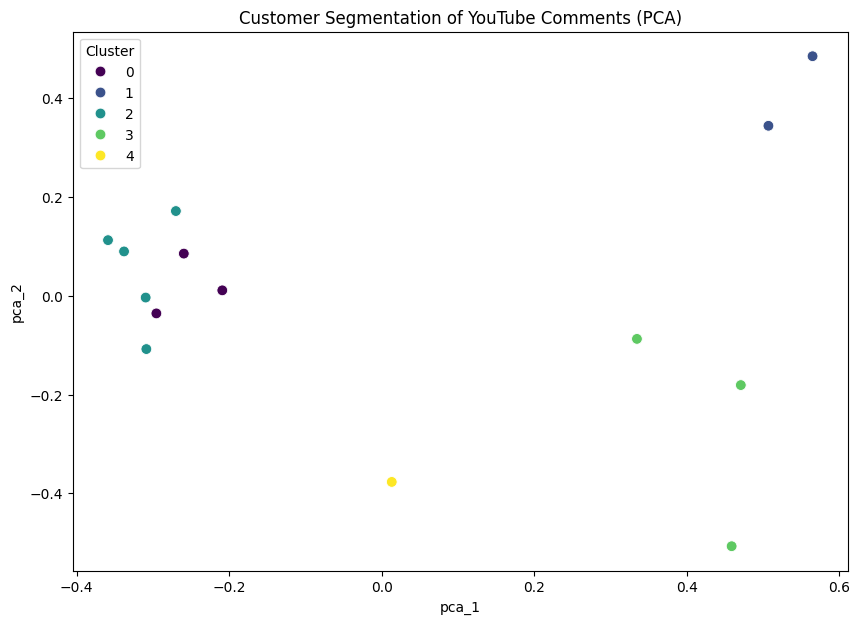

In [47]:
# ติดตั้ง library: pip install scikit-learn matplotlib seaborn
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Clustering
num_clusters = 5
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(embeddings)

# 4. Visualization ด้วย PCA
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embeddings)

df['pca_1'] = reduced_embeddings[:, 0]
df['pca_2'] = reduced_embeddings[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='pca_1', y='pca_2', hue='Cluster', palette='viridis', s=60)
plt.title('Customer Segmentation of YouTube Comments (PCA)')
plt.show()

In [51]:
# 1. ฟังก์ชันแปลง DataFrame เป็น Markdown Table (ตามแนวทาง Shaw Talebi)
def dataframe_to_markdown(df):
    markdown = f"| {' | '.join(df.columns)} |\\n"
    markdown += f"| {' | '.join(['---' for _ in df.columns])} |\\n"
    for _, row in df.iterrows():
        markdown += f"| {' | '.join(str(cell).replace('\\n', ' ') for cell in row)} |\\n"
    return markdown

# 2. Template สำหรับ Prompt
prompt_template = lambda markdown_table: f"""คุณคือผู้เชี่ยวชาญด้านกลยุทธ์ธุรกิจและการวิเคราะห์ลูกค้า 
ด้านล่างนี้คือตารางคอมเมนต์จาก YouTube ที่ถูกจัดกลุ่มมาแล้ว 
งานของคุณคือวิเคราะห์คอมเมนต์เหล่านี้และสร้าง **Customer Persona** ที่โดดเด่นของกลุ่มนี้

กรุณาสรุปข้อมูลดังนี้ (ใช้ภาษาไทย):
1. **ชื่อกลุ่ม (Persona Name)**: ชื่อที่สะท้อนบุคลิกของกลุ่มนี้
2. **ความสนใจ/พฤติกรรม (Interests/Behaviors)**: พวกเขาสนใจเรื่องอะไร หรือมีพฤติกรรมอย่างไร
3. **อารมณ์ความรู้สึก (Sentiment)**: อารมณ์โดยรวมต่อวิดีโอ (บวก/ลบ/สงสัย)

### ข้อมูลคอมเมนต์
{markdown_table}

### คำสั่งเพิ่มเติม:
- สรุปให้กระชับ ได้ใจความ
- ตอบเป็นหัวข้อที่กำหนดเท่านั้น
"""

# 3. ฟังก์ชันเรียก Gemini เพื่อสร้าง Persona
def generate_persona_gemini(df_segment):
    model = genai.GenerativeModel('gemini-2.5-flash')
    # สุ่มตัวอย่างคอมเมนต์ 15 ข้อความเพื่อไม่ให้ Token เกิน
    sample_data = df_segment[['Author', 'Comment Text']].sample(min(15, len(df_segment)))
    markdown_text = dataframe_to_markdown(sample_data)
    
    response = model.generate_content(prompt_template(markdown_text))
    return response.text

# 4. วนลูปสร้าง Persona ทุกกลุ่ม
print("\\n--- สรุปผลการวิเคราะห์ Persona ---")
summary_list = []
# วนลูปตามกลุ่มที่มีอยู่จริงในข้อมูล
for i in sorted(df['Cluster'].unique()):
    segment_data = df[df['Cluster'] == i]
    print(f"กำลังวิเคราะห์ Segment {i} (ขนาด: {len(segment_data)} คอมเมนต์)....")
    analysis = generate_persona_gemini(segment_data)
    summary_list.append({'Segment': i, 'Analysis': analysis})

# แสดงผลลัพธ์
for item in summary_list:
    print(f"\\n{'='*50}\\nSegment {item['Segment']}\\n{'='*50}")
    print(item['Analysis'])

\n--- สรุปผลการวิเคราะห์ Persona ---
กำลังวิเคราะห์ Segment 0 (ขนาด: 3 คอมเมนต์)....
กำลังวิเคราะห์ Segment 1 (ขนาด: 2 คอมเมนต์)....
กำลังวิเคราะห์ Segment 2 (ขนาด: 5 คอมเมนต์)....
กำลังวิเคราะห์ Segment 3 (ขนาด: 3 คอมเมนต์)....
กำลังวิเคราะห์ Segment 4 (ขนาด: 1 คอมเมนต์)....
\n==================================================\nSegment 0\n==================================================
นี่คือ Customer Persona จากข้อมูลคอมเมนต์ที่ได้รับ:

1.  **ชื่อกลุ่ม (Persona Name)**: ผู้เชี่ยวชาญด้าน AI & Data Science เชิงลึก (The Deep Dive AI & Data Science Expert)

2.  **ความสนใจ/พฤติกรรม (Interests/Behaviors)**:
    *   สนใจเทคนิค Machine Learning และ Data Science ขั้นสูง โดยเฉพาะอย่างยิ่งเรื่อง Embedding Models, Natural Language Processing (NLP) และการวิเคราะห์ข้อมูลเชิงลึก
    *   ต้องการความรู้ที่นำไปใช้งานได้จริง (hands-on), คำแนะนำเชิงปฏิบัติ, และแนวทางแก้ปัญหาในสถานการณ์จริง (เช่น การจัดการ Bias หรือ Subjectivity ในโมเดล)
    *   มีพฤติกรรมตั้งคำถามเชิงลึกเกี่ยวกับหลักการ, เหตุผลเบื้อง